In [9]:
from pathlib import Path
import sys
import cv2
import importlib
import pandas as pd
import numpy as np

import scripts.follow_the_mouse
import scripts.fit_homographies # for the read_frame function

sys.path.append(str(Path().resolve().parent))

import scripts.follow_the_mouse as ftm
importlib.reload(ftm)

import scripts.fit_homographies as fh
importlib.reload(fh)

<module 'scripts.fit_homographies' from '/Users/zosiasus/Documents/Aeon3_SLEAP/AEON_sleap_analysis/scripts/fit_homographies.py'>

# Create a composite video that tracks the instance 

In [15]:
DATA_PATH = Path("/Volumes/homes/live/zsus/aeon_sleap/abcEphysPilot01/processed/homographies/homographies_CameraTop_to_sides_thresh10px.npz")
OUT_PATH = Path("/Volumes/homes/live/zsus/aeon_sleap/abcEphysPilot01/processed/videos/")

REF_CAMERA = "CameraTop"
SIDE_CAMERAS = ["CameraEast", "CameraNorth", "CameraSouth", "CameraWest", "CameraNest"]


In [16]:
top_video_path = Path("/Volumes/aeon/aeon/data/raw/AEON3/abcEphysPilot01/2026-04-14T141851Z_calibrateBeforeAprilExperiments/CameraTop/CameraTop_2026-04-14T14-00-00.avi")
top0 = fh._read_frame(top_video_path, 0)

In [23]:
best_cam_idx, xs, ys = ftm.build_preference_map(
    homography_path=DATA_PATH,
    top_frame=top0,
    side_cameras=SIDE_CAMERAS,
    cam_wh={
        "CameraNorth": (1920, 1080),
        "CameraSouth": (1920, 1080),
        "CameraEast":  (1920, 1080),
        "CameraWest":  (1920, 1080),
    }
)

Preference map built: 108×144 grid over 1440×1080 px


In [44]:
rois = [
    ftm.ROI.rect("nest", REF_CAMERA, 1200, 500, 1000, 400, color=(0,255,0)),
    ftm.ROI.circle("patch_1", REF_CAMERA, 500, 600, 120, color=(255,0,0)),
]

plexi_line = ftm.PlexiLine(
    p1=(10, 300),
    p2=(600, 300),
    left_cameras=["CameraEast", "CameraSouth"],
    right_cameras=["CameraNorth", "CameraWest"]
)

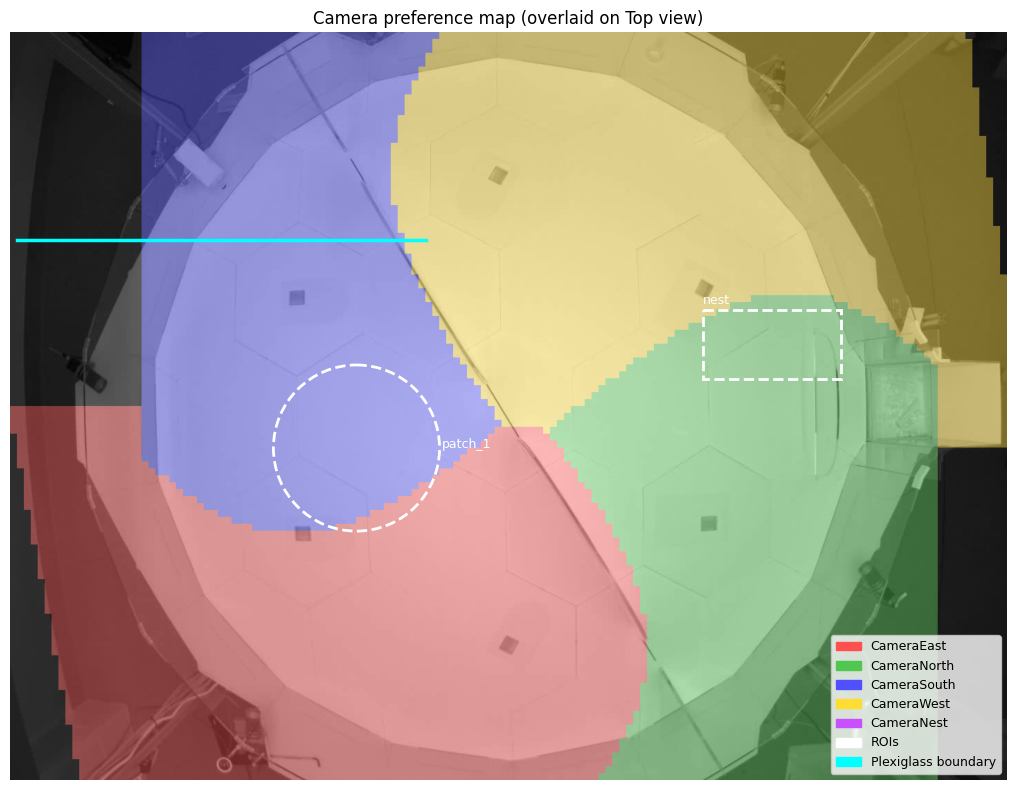

In [45]:
ftm.visualise_preference_map(
    best_cam_idx=best_cam_idx,
    xs=xs,
    ys=ys,
    top_frame=top0,
    side_cameras=SIDE_CAMERAS,
    rois=rois,
    plexi_line=plexi_line,
    )